# 01 Market Data Basics

The goal is to understand basic market data, compute returns, and get comfortable reading price data before moving to factors and backtesting.

Work through the notebook from top to bottom. Each section has a short explanation and one code cell to run.


## Notebook goals

- Understand OHLCV and adjusted close
- Compute simple return and log return
- Check for missing values
- Plot price and return charts
- Save a small sample dataset for later weeks


## What you need

Before running the notebook, make sure these packages are installed:

```bash
pip install pandas numpy matplotlib yfinance pyarrow
```

If you use a virtual environment, activate it first.


## 1. Import libraries

Run the next cell to import the libraries used in this notebook. If one import fails, install the missing package and run the cell again.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)


## 2. Choose sample tickers

Use five sample tickers for this notebook:

- SPY
- QQQ
- AAPL
- MSFT
- TSLA

You can change them later, but it is better to follow the default set first.


In [4]:
tickers = ["SPY", "QQQ", "AAPL", "MSFT"]
start_date = "2018-01-01"
end_date = "2025-12-31"

tickers, start_date, end_date


(['SPY', 'QQQ', 'AAPL', 'MSFT'], '2018-01-01', '2025-12-31')

## 3. Download market data from Yahoo Finance

Run the next cell to download historical data. If Yahoo Finance fails or your network is unstable, run it again once. If it still fails, try a shorter date range first.


In [5]:
raw = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False
)

raw.head()


Price       Adj Close                                         Close                                          High  \
Ticker           AAPL       MSFT         QQQ         SPY       AAPL       MSFT         QQQ         SPY       AAPL   
Date                                                                                                                
2018-01-02  40.267071  78.699898  150.222153  236.562149  43.064999  85.949997  158.490005  268.769989  43.075001   
2018-01-03  40.260071  79.066147  151.681808  238.058441  43.057499  86.349998  160.029999  270.470001  43.637501   
2018-01-04  40.447067  79.762070  151.947174  239.061783  43.257500  87.110001  160.309998  271.609985  43.367500   
2018-01-05  40.907578  80.750977  153.473175  240.654953  43.750000  88.190002  161.919998  273.420013  43.842499   
2018-01-08  40.755627  80.833359  154.070343  241.095016  43.587502  88.279999  162.550003  273.920013  43.902500   

Price                  ...         Low                   Open                                        Volume            \
Ticker           MSFT  ...         QQQ         SPY       AAPL       MSFT         QQQ         SPY       AAPL      MSFT   
Date                   ...                                                                                              
2018-01-02  86.309998  ...  156.169998  267.399994  42.540001  86.129997  156.559998  267.839996  102223600  22483800   
2018-01-03  86.510002  ...  158.610001  268.959991  43.132500  86.059998  158.639999  268.959991  118071600  26061400   
2018-01-04  87.660004  ...  160.080002  270.540009  43.134998  86.589996  160.580002  271.200012   89738400  21912000   
2018-01-05  88.410004  ...  160.770004  271.950012  43.360001  87.660004  161.070007  272.510010   94640000  23407100   
2018-01-08  88.580002  ...  161.860001  272.980011  43.587502  88.199997  161.919998  273.309998   82271200  22113000   

Price                           
Ticker           QQQ       SPY  
Date                            
2018-01-02  32573300  86655700  
2018-01-03  29383600  90070400  
2018-01-04  24776100  80636400  
2018-01-05  26992300  83524000  
2018-01-08  23159100  57319200  

[5 rows x 24 columns]

## 4. Inspect the dataset structure

After downloading the data, check three things:

1. How many rows and columns the dataset has
2. Whether the columns use a MultiIndex
3. Whether missing values exist

This step matters because return calculations are only meaningful when you understand the dataset shape first.


In [6]:
raw.info()

display(raw.head())
display(raw.tail())

raw.isna().sum()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2010 entries, 2018-01-02 to 2025-12-30
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, AAPL)  2010 non-null   float64
 1   (Adj Close, MSFT)  2010 non-null   float64
 2   (Adj Close, QQQ)   2010 non-null   float64
 3   (Adj Close, SPY)   2010 non-null   float64
 4   (Close, AAPL)      2010 non-null   float64
 5   (Close, MSFT)      2010 non-null   float64
 6   (Close, QQQ)       2010 non-null   float64
 7   (Close, SPY)       2010 non-null   float64
 8   (High, AAPL)       2010 non-null   float64
 9   (High, MSFT)       2010 non-null   float64
 10  (High, QQQ)        2010 non-null   float64
 11  (High, SPY)        2010 non-null   float64
 12  (Low, AAPL)        2010 non-null   float64
 13  (Low, MSFT)        2010 non-null   float64
 14  (Low, QQQ)         2010 non-null   float64
 15  (Low, SPY)         2010 non-null   float64
 16  (Open,

Price       Adj Close                                         Close                                          High  \
Ticker           AAPL       MSFT         QQQ         SPY       AAPL       MSFT         QQQ         SPY       AAPL   
Date                                                                                                                
2018-01-02  40.267071  78.699898  150.222153  236.562149  43.064999  85.949997  158.490005  268.769989  43.075001   
2018-01-03  40.260071  79.066147  151.681808  238.058441  43.057499  86.349998  160.029999  270.470001  43.637501   
2018-01-04  40.447067  79.762070  151.947174  239.061783  43.257500  87.110001  160.309998  271.609985  43.367500   
2018-01-05  40.907578  80.750977  153.473175  240.654953  43.750000  88.190002  161.919998  273.420013  43.842499   
2018-01-08  40.755627  80.833359  154.070343  241.095016  43.587502  88.279999  162.550003  273.920013  43.902500   

Price                  ...         Low                   Open                                        Volume            \
Ticker           MSFT  ...         QQQ         SPY       AAPL       MSFT         QQQ         SPY       AAPL      MSFT   
Date                   ...                                                                                              
2018-01-02  86.309998  ...  156.169998  267.399994  42.540001  86.129997  156.559998  267.839996  102223600  22483800   
2018-01-03  86.510002  ...  158.610001  268.959991  43.132500  86.059998  158.639999  268.959991  118071600  26061400   
2018-01-04  87.660004  ...  160.080002  270.540009  43.134998  86.589996  160.580002  271.200012   89738400  21912000   
2018-01-05  88.410004  ...  160.770004  271.950012  43.360001  87.660004  161.070007  272.510010   94640000  23407100   
2018-01-08  88.580002  ...  161.860001  272.980011  43.587502  88.199997  161.919998  273.309998   82271200  22113000   

Price                           
Ticker           QQQ       SPY  
Date                            
2018-01-02  32573300  86655700  
2018-01-03  29383600  90070400  
2018-01-04  24776100  80636400  
2018-01-05  26992300  83524000  
2018-01-08  23159100  57319200  

[5 rows x 24 columns]

Price        Adj Close                                           Close                                      \
Ticker            AAPL        MSFT         QQQ         SPY        AAPL        MSFT         QQQ         SPY   
Date                                                                                                         
2025-12-23  271.854919  484.691528  621.326538  686.086304  272.359985  486.850006  622.109985  687.960022   
2025-12-24  273.302216  485.856323  623.144287  688.499695  273.809998  488.019989  623.929993  690.380005   
2025-12-26  272.893005  485.547699  623.104309  688.429871  273.399994  487.709991  623.890015  690.309998   
2025-12-29  273.252350  484.940430  620.088135  685.976562  273.760010  487.100006  620.869995  687.849976   
2025-12-30  272.573547  485.318726  618.649902  685.138916  273.079987  487.480011  619.429993  687.010010   

Price             High              ...         Low                    Open                                      \
Ticker            AAPL        MSFT  ...         QQQ         SPY        AAPL        MSFT         QQQ         SPY   
Date                                ...                                                                           
2025-12-23  272.500000  487.829987  ...  617.780029  683.869995  270.839996  484.980011  618.200012  683.919983   
2025-12-24  275.429993  489.160004  ...  621.719971  687.799988  272.339996  485.679993  621.989990  687.950012   
2025-12-26  275.369995  488.119995  ...  623.140015  689.270020  274.160004  486.709991  624.659973  690.640015   
2025-12-29  274.359985  488.350006  ...  618.729980  686.070007  272.690002  484.859985  620.099976  687.539978   
2025-12-30  274.079987  489.679993  ...  619.219971  686.580017  272.809998  485.929993  619.840027  687.450012   

Price         Volume                                
Ticker          AAPL      MSFT       QQQ       SPY  
Date                                                
2025-12-23  29642000  14683600  41120400  64840000  
2025-12-24  17910600   5855900  18468700  39445600  
2025-12-26  21521800   8842200  28959800  41613300  
2025-12-29  23715200  10893400  32458300  62559500  
2025-12-30  22139600  13944500  31226800  47160700  

[5 rows x 24 columns]

Price      Ticker
Adj Close  AAPL      0
           MSFT      0
           QQQ       0
           SPY       0
Close      AAPL      0
           MSFT      0
           QQQ       0
           SPY       0
High       AAPL      0
           MSFT      0
           QQQ       0
           SPY       0
Low        AAPL      0
           MSFT      0
           QQQ       0
           SPY       0
Open       AAPL      0
           MSFT      0
           QQQ       0
           SPY       0
Volume     AAPL      0
           MSFT      0
           QQQ       0
           SPY       0
dtype: int64

## 5. Extract adjusted close

For longer-term backtests, adjusted close is usually better than close because it accounts for stock splits and dividends.

In this step, isolate the `Adj Close` data into a simpler table.


In [7]:
adj_close = raw["Adj Close"].copy()

display(adj_close.head())
adj_close.columns


Ticker,AAPL,MSFT,QQQ,SPY
Date,,,,
2018-01-02,40.267071,78.699898,150.222153,236.562149
2018-01-03,40.260071,79.066147,151.681808,238.058441
2018-01-04,40.447067,79.762070,151.947174,239.061783
2018-01-05,40.907578,80.750977,153.473175,240.654953
2018-01-08,40.755627,80.833359,154.070343,241.095016


Index(['AAPL', 'MSFT', 'QQQ', 'SPY'], dtype='object', name='Ticker')

## 6. Compute simple return and log return

Returns should be computed from adjusted close. Use these formulas:

- Simple return: `price_t / price_{t-1} - 1`
- Log return: `log(price_t / price_{t-1})`

Run the next cell and compare the two return tables for the same ticker.


In [8]:
simple_returns = adj_close.pct_change()
log_returns = np.log(adj_close / adj_close.shift(1))

display(simple_returns.head())
display(log_returns.head())


Ticker,AAPL,MSFT,QQQ,SPY
Date,,,,
2018-01-02,NaN,NaN,NaN,NaN
2018-01-03,-0.000174,0.004654,0.009717,0.006325
2018-01-04,0.004645,0.008802,0.001749,0.004215
2018-01-05,0.011386,0.012398,0.010043,0.006664
2018-01-08,-0.003714,0.001020,0.003891,0.001829


Ticker,AAPL,MSFT,QQQ,SPY
Date,,,,
2018-01-02,NaN,NaN,NaN,NaN
2018-01-03,-0.000174,0.004643,0.009670,0.006305
2018-01-04,0.004634,0.008763,0.001748,0.004206
2018-01-05,0.011321,0.012322,0.009993,0.006642
2018-01-08,-0.003721,0.001020,0.003883,0.001827


## 7. Plot the data

Start with one ticker, for example `SPY`. If the plot works, switch to `TSLA` or `QQQ` and compare the behavior.

The goal here is not to build polished charts. The goal is to see the trend and the return distribution clearly.


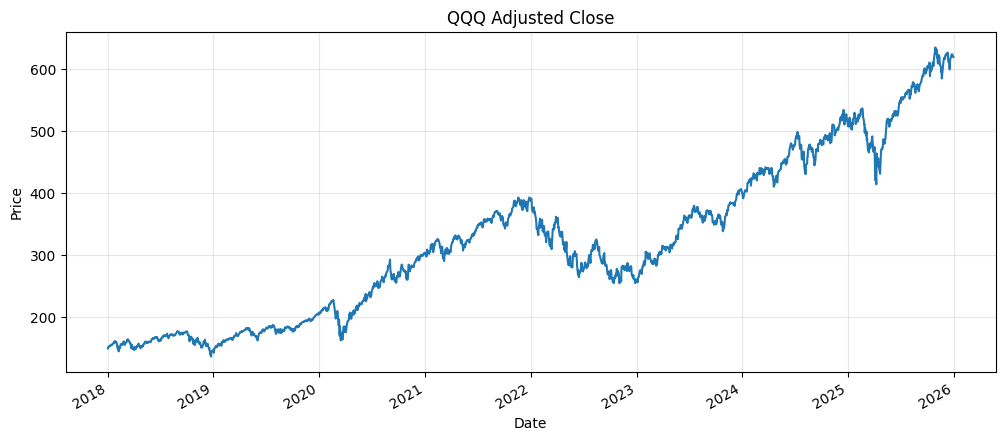

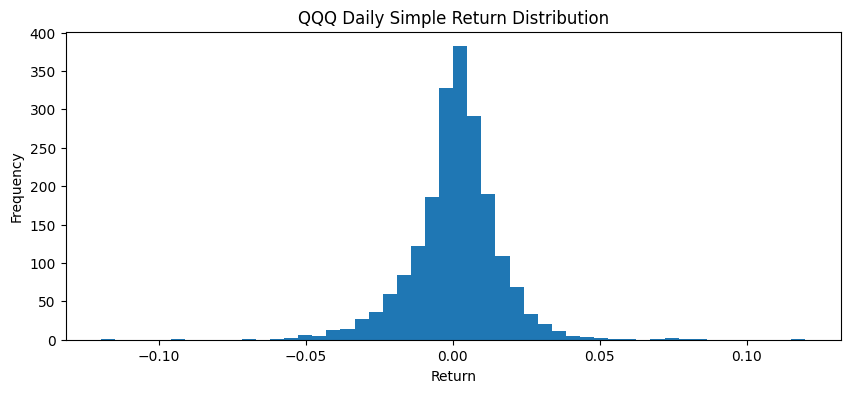

In [11]:
ticker = "QQQ"

plt.figure(figsize=(12, 5))
adj_close[ticker].plot()
plt.title(f"{ticker} Adjusted Close")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
simple_returns[ticker].dropna().hist(bins=50)
plt.title(f"{ticker} Daily Simple Return Distribution")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.grid(False)
plt.show()


## 8. Compute a few simple statistics

A quick way to compare tickers is to look at daily volatility. This is not a full factor yet. It is just a simple way to get familiar with the data.


Ticker
AAPL    0.019401
MSFT    0.017861
QQQ     0.015153
SPY     0.012260
dtype: float64

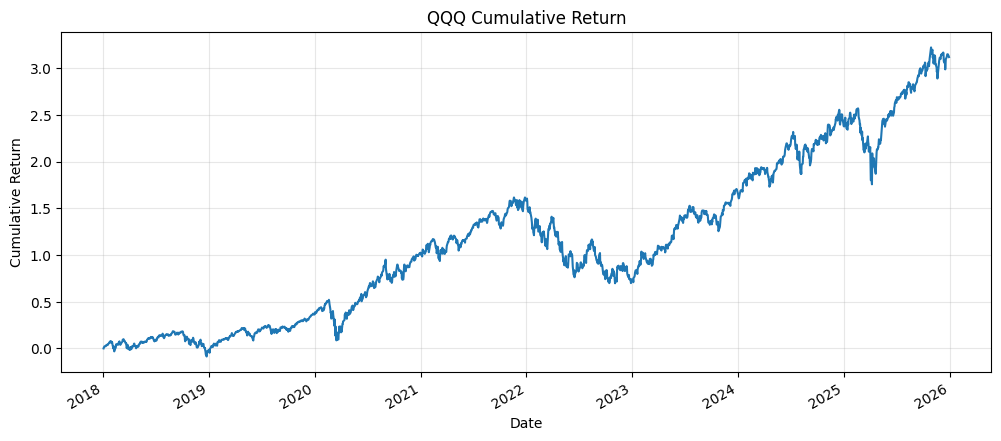

In [12]:
daily_vol = simple_returns.std().sort_values(ascending=False)
display(daily_vol)

cumulative_returns = (1 + simple_returns.fillna(0)).cumprod() - 1

plt.figure(figsize=(12, 5))
cumulative_returns[ticker].plot()
plt.title(f"{ticker} Cumulative Return")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True, alpha=0.3)
plt.show()


## 9. Save a local sample dataset

If everything works, save one parquet file for later weeks. The file should go into `data/raw/` and should not be committed to Git.

If `pyarrow` is missing, this step will fail. Install it and run the cell again.


In [13]:
output_path = "../data/raw/week1_sample_prices.parquet"
adj_close.to_parquet(output_path)
output_path


'../data/raw/week1_sample_prices.parquet'

## 10. Questions to answer yourself

After running the notebook, write short answers to these questions in the notebook or in `docs/quant_notes_week1.md`:

1. Why is adjusted close usually better than close for long-term backtests?
2. Which ticker looks the most volatile in the sample?
3. Does the return distribution look centered around 0?
4. How could missing data distort later analysis?


## 11. Finish

If you finish this notebook, you have completed the foundation for Week 1 Day 2. The next step is to write short notes about OHLCV, adjusted close, simple return, and log return.
